Install the latest `pyrealm` version

In [1]:
pip install pyrealm==2.0.0rc4

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install netCDF4

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 19.6 MB/s eta 0:00:0031m21.2 MB/s eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 22.1 MB/s eta 0:00:0031m25.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 15.2 MB/s eta 0:00:00 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# Worked examples

This page shows two worked examples of how to use `pyrealm` to make predictions using
the P Model.

The first example uses a single point but the second shows how the package can be used
with array data. The `pyrealm` package uses the `numpy` package and expects arrays of
data to be be passed to all inputs. Input arrays can be a single scalar value, but all
non-scalar inputs must be **arrays with the same shape**: the `pyrealm` packages does
not attempt to resolve the broadcasting of array dimensions.

In [7]:
import numpy as np
import xarray
from matplotlib import pyplot as plt

from pyrealm.core.pressure import calc_patm
from pyrealm.pmodel import PModelEnvironment
from pyrealm.pmodel.pmodel import PModel

## Warning

The `pyrealm` package uses a modular approach to define many of the shared
components of the standard and subdaily P Model.
Some combinations of the methods implemented may modify the same aspect of the model
using different approaches.

As an example, there are multiple approaches to incorporating effects of
soil_moisture.md on productivity, via
modulation of $\phi_0$, $m_j$ and the calculation of GPP penalty factors.

At present, `pyrealm` does not automatically check the compatibility of method
selection, so take care when setting methods options for fitting a P Model.

## Simple point estimate

This example calculates a single point estimate of GPP. The first step is to use
estimates of environmental variables to calculate the
photosynthetic environment for the model
PModelEnvironment.

The example shows the steps required using a single site with:

* a temperature of 20°C,
* standard atmospheric at sea level (101325 Pa),
* a vapour pressure deficit of 0.82 kPa (~ 65% relative humidity), and
* an atmospheric $CO_2$ concentration of 400 ppm.

### Estimating productivity

The PModelEnvironment also accepts estimates
of the fraction of absorbed photosynthetically active radiation ($f_{APAR}$, `fapar`,
unitless) and the photosynthetic photon flux density (PPFD,`ppfd`, µmol m-2 s-1).
Together these are used to calculate the asorbed irradiance, which is used to scale up
the estimated light use efficiency to estimate the actual productivity of the model.
Here we are using:

* An absorption fraction of 0.91 (-), and
* a PPFD of 834 µmol m-2 s-1.

## Warning
In the PModelEnvironment, the estimated PPFD
must be expressed as **µmol m-2 s-1**.

Estimates of PPFD sometimes use different temporal or spatial scales - for
example daily moles of photons per hectare. Although GPP can also be expressed
with different units, many other predictions of the P Model ($J_{max}$,
$V_{cmax}$, $g_s$ and $r_d$) _must_ be expressed as µmol m-2 s-1 and so this
standard unit must also be used for PPFD.

# Calculate the PModelEnvironment

In [8]:
env = PModelEnvironment(tc=20.0, patm=101325.0, vpd=820, co2=400, fapar=0.91, ppfd=834)
env

PModelEnvironment(shape=(1,))

The `env` object now holds the photosynthetic environment, which can be re-used with
different P Model settings. The representation of a
PModelEnvironment object (`env`) is
deliberately terse - just the shape of the data - but the
`PModelEnvironment.summarize`
method provides a more detailed summary of the attributes.

In [9]:
env.summarize()

PModelEnvironment(shape=(1,))
Attr            Mean        Min        Max    NaN  Units
---------  ---------  ---------  ---------  -----  ------------
tc             20         20         20         0  °C
vpd           820        820        820         0  Pa
co2           400        400        400         0  ppm
patm       101325     101325     101325         0  Pa
fapar           0.91       0.91       0.91      0  -
ppfd          834        834        834         0  µmol m-2 s-1
ca             40.53      40.53      40.53      0  Pa
gammastar       3.34       3.34       3.34      0  Pa
kmm            46.1       46.1       46.1       0  Pa
ns_star         1.13       1.13       1.13      0  -


### Fitting the P Model

Next, the P Model can be fitted to the photosynthetic environment using the
PModel class:

In [10]:
model = PModel(env)

pyrealm/pmodel.py:409: UserWarning: 
    Pyrealm 2.0.0 uses a new default for the quantum yield of photosynthesis (phi0=1/8).
    You may need to change settings to duplicate results from pyrealm 1.0.0.
            


The returned model object holds a lot of information. The representation of the
model object shows a terse display of the settings used to run the model:

In [11]:
model

PModel(shape=(1,), method_optchi=prentice14, method_arrhenius=simple, method_jmaxlim=wang17, method_kphio=temperature)

A PModel instance also has a `PModel.summarize` method that summarizes settings and
displays a summary of calculated predictions. Initially, this shows two measures of
photosynthetic efficiency: the intrinsic water use efficiency (``iwue``) and the light
use efficiency (``lue``).

In [12]:
model.summarize()

PModel(shape=(1,), method_optchi=prentice14, method_arrhenius=simple, method_jmaxlim=wang17, method_kphio=temperature)
Attr       Mean     Min     Max    NaN  Units
-------  ------  ------  ------  -----  ------------
lue        0.4     0.4     0.4       0  g C mol-1
iwue      71.44   71.44   71.44      0  µmol mol-1
gpp      300.22  300.22  300.22      0  µg C m-2 s-1
vcmax     73.25   73.25   73.25      0  µmol m-2 s-1
vcmax25  114.82  114.82  114.82      0  µmol m-2 s-1
gs         2.16    2.16    2.16      0  µmol m-2 s-1
jmax     167.72  167.72  167.72      0  µmol m-2 s-1
jmax25   226.87  226.87  226.87      0  µmol m-2 s-1


### $\chi$ estimates and $CO_2$ limitation

The instance also contains a `OptimalChiPrentice14`
object,
recording key parameters from the calculation of
$\chi$.
This object also has a `OptimalChiABC.summarize`
method:

In [13]:
model.optchi.summarize()

OptimalChiPrentice14(shape=(1,))
Attr      Mean    Min    Max    NaN  Units
------  ------  -----  -----  -----  ----------
xi       63.31  63.31  63.31      0  Pa ^ (1/2)
chi       0.71   0.71   0.71      0  -
mc        0.34   0.34   0.34      0  -
mj        0.72   0.72   0.72      0  -
mjoc      2.11   2.11   2.11      0  -



## 3D grid example

This example shows how the `pmodel` module can be used with array inputs
to calculate a global map of gross primary productivity (GPP).

First, we load some
example data from a NetCDF format file using the excellent `xarray` package.
These data are 0.5° global grids containing data for 2 months and so the loaded
data are three dimensional arrays and shape `(2, 360, 720)` . Note that the arrays have
to be the same size so some of the variables have repeated data across dimensions:

* The CO2 data is globally constant for each month, but the values are repeated for each
  cell.
* Elevation is constant across months, so the data for each month is repeated.

In [14]:
pip install wget

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9685 sha256=a9adb9fd0ccedf55e665b5151e2b9d78767b6f39c5a5a3dcf677797f8ce76e9a
  Stored in directory: /home/marion/.cache/pip/wheels/8a/b8/04/0c88fb22489b0c049bee4e977c5689c7fe597d6c4b0e7d0b6a
Successfully built wget
Note: you may need to restart the kernel to use updated packages.


In [15]:
import wget

wget.download(
    "https://github.com/ImperialCollegeLondon/pyrealm/raw/develop/pyrealm_build_data/rpmodel/pmodel_global.nc"
)

100% [....................................................] 12489826 / 12489826

'pmodel_global.nc'

In [16]:
ds = xarray.load_dataset("pmodel_global.nc")

# Extract the six variables for the two months and convert from
# xarray DataArray objects to numpy arrays
temp = ds["temp"].to_numpy()
co2 = ds["CO2"].to_numpy()
elev = ds["elevation"].to_numpy()
vpd = ds["VPD"].to_numpy()
fapar = ds["fAPAR"].to_numpy()
ppfd = ds["ppfd"].to_numpy()

The model can now be run using that data. The first step is to convert the elevation
data to atmospheric pressure, and then this is used to set the photosynthetic
environment for the model:

In [17]:
# Convert elevation to atmospheric pressure
patm = calc_patm(elev)

# Mask out temperature values below -25°C
temp[temp < -25] = np.nan

# Clip VPD to force negative VPD to be zero
vpd = np.clip(vpd, 0, np.inf)

# Calculate the photosynthetic environment
env = PModelEnvironment(tc=temp, co2=co2, patm=patm, vpd=vpd, fapar=fapar, ppfd=ppfd)
env.summarize()

pyrealm/bounds.py:165: UserWarning: Variable 'ppfd' (µmol m-2 s-1) contains values outside the expected range (0,3000). Check units?


PModelEnvironment(shape=(2, 360, 720))
Attr           Mean       Min        Max     NaN  Units
---------  --------  --------  ---------  ------  ------------
tc             4.11    -25         33.6   387580  °C
vpd         1119.03      2.76    5379.87  332622  Pa
co2          390.68    390.2      391.17       0  ppm
patm       97367.9   50317.1   102175          0  Pa
fapar          0.32      0          0.99  414897  -
ppfd       38690.1       0     254494          0  µmol m-2 s-1
ca            38.04     19.63      39.97       0  Pa
gammastar      2.04      0.12       6.53  387580  Pa
kmm           31.46      0.62     147.5   387580  Pa
ns_star        2.42      0.83       6.44  387580  -


That environment can then be run to calculate the P model predictions for GPP:


pyrealm/pmodel.py:409: UserWarning: 
    Pyrealm 2.0.0 uses a new default for the quantum yield of photosynthesis (phi0=1/8).
    You may need to change settings to duplicate results from pyrealm 1.0.0.
            


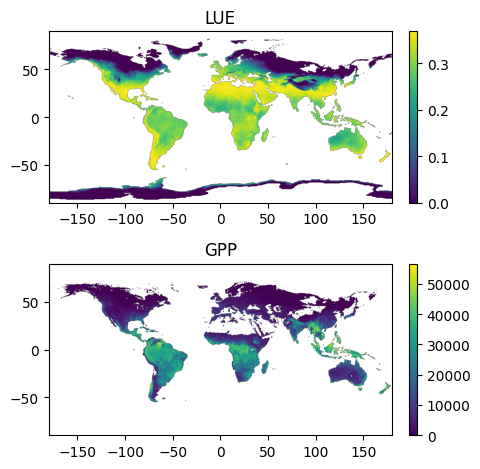

In [18]:
# Run the P model
model = PModel(env)

fig, (ax1, ax2) = plt.subplots(2, 1)

# Plot LUE for first month
im = ax1.imshow(model.lue[0, :, :], origin="lower", extent=[-180, 180, -90, 90])
plt.colorbar(im, fraction=0.022, pad=0.03, ax=ax1)
ax1.set_title("LUE")

im = ax2.imshow(model.gpp[0, :, :], origin="lower", extent=[-180, 180, -90, 90])
plt.colorbar(im, fraction=0.022, pad=0.03, ax=ax2)
ax2.set_title("GPP")

plt.tight_layout()